# Label visualization

This notebook overlays label bounding boxes on the original document image.

In [8]:
from pathlib import Path
import json
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

Documents:
0: 001_cl_23032-12.pdf_0.png
1: 002_cl_23032-12.pdf_14.png
2: 004_cl_23032-12.pdf_7.png
3: 004_cl_23032-12.pdf_7c1.png
4: 004_cl_23032-12.pdf_7c2.png


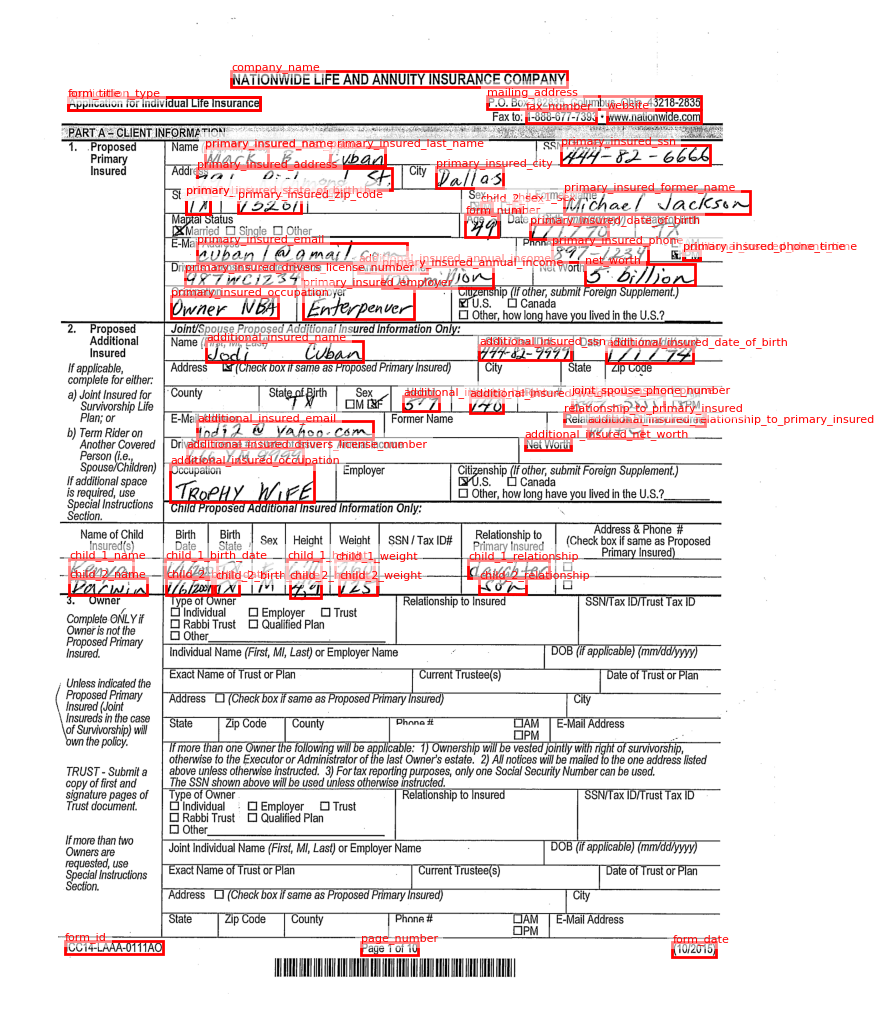

In [9]:
data_dir = Path("training_data")
if not data_dir.exists():
    candidate = Path.cwd() / "example" / "gpt_labeling_pipeline" / "training_data"
    if candidate.exists():
        data_dir = candidate

supported_exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
document_paths = sorted(
    path
    for path in data_dir.iterdir()
    if path.is_file() and path.suffix.lower() in supported_exts
)

if not document_paths:
    raise FileNotFoundError(f"No documents found in {data_dir}")

print("Documents:")
for idx, path in enumerate(document_paths):
    print(f"{idx}: {path.name}")

def load_json(path):
    data = path.read_bytes()
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return json.loads(data.decode(encoding))
        except (UnicodeDecodeError, json.JSONDecodeError):
            continue
    return json.loads(data.decode("utf-8", errors="replace"))

def display_document(index):
    image_path = document_paths[index]
    labels_path = image_path.with_name(image_path.name + ".labels.json")
    if not labels_path.exists():
        raise FileNotFoundError(f"Labels file not found: {labels_path}")
    image = Image.open(image_path)
    labels_payload = load_json(labels_path)

    fig, ax = plt.subplots(figsize=(10, 13))
    ax.imshow(image)
    current_page = 1
    for entry in labels_payload.get("labels", []):
        label_name = entry.get("label") or entry.get("field")
        value_entries = entry.get("value")
        if isinstance(value_entries, list) and value_entries:
            for value_entry in value_entries:
                page = value_entry.get("page")
                if page is None:
                    page = value_entry.get("pageNumber")
                if page not in (None, current_page):
                    continue
                boxes = value_entry.get("boundingBoxes") or []
                for box in boxes:
                    if len(box) < 8:
                        continue
                    points = list(zip(box[::2], box[1::2]))
                    if max(box) <= 1:
                        points = [(x * image.width, y * image.height) for x, y in points]
                    patch = Polygon(points, fill=False, linewidth=2, edgecolor="red")
                    ax.add_patch(patch)
                    if label_name:
                        ax.text(
                            points[0][0],
                            points[0][1] - 4,
                            label_name,
                            color="red",
                            fontsize=8,
                            bbox={"facecolor": "white", "alpha": 0.5, "edgecolor": "none"},
                        )
        else:
            for region in entry.get("boundingRegions", []):
                polygon = region.get("polygon") or []
                if len(polygon) < 8:
                    continue
                page = region.get("pageNumber")
                if page is not None and page != current_page:
                    continue
                points = list(zip(polygon[::2], polygon[1::2]))
                if max(polygon) <= 1:
                    points = [(x * image.width, y * image.height) for x, y in points]
                patch = Polygon(points, fill=False, linewidth=2, edgecolor="red")
                ax.add_patch(patch)
                if label_name:
                    ax.text(
                        points[0][0],
                        points[0][1] - 4,
                        label_name,
                        color="red",
                        fontsize=8,
                        bbox={"facecolor": "white", "alpha": 0.5, "edgecolor": "none"},
                    )

    ax.axis("off")
    plt.show()

display_document(0)

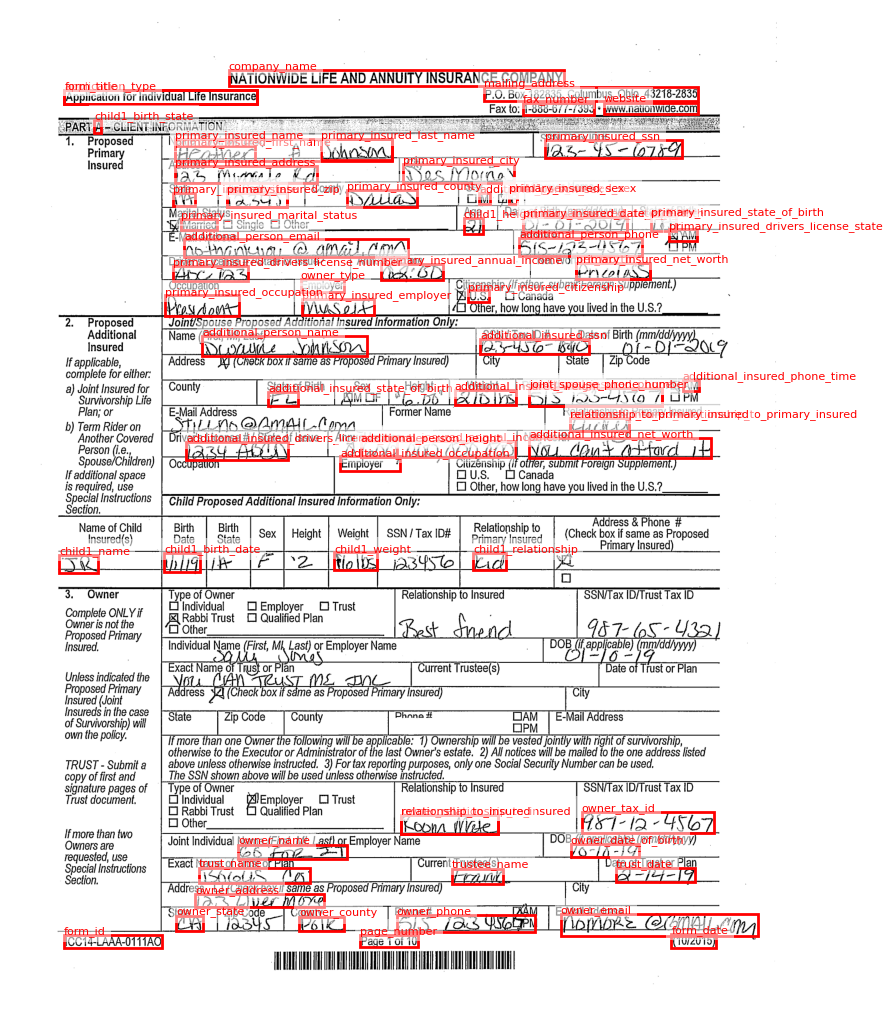

In [10]:
display_document(1)

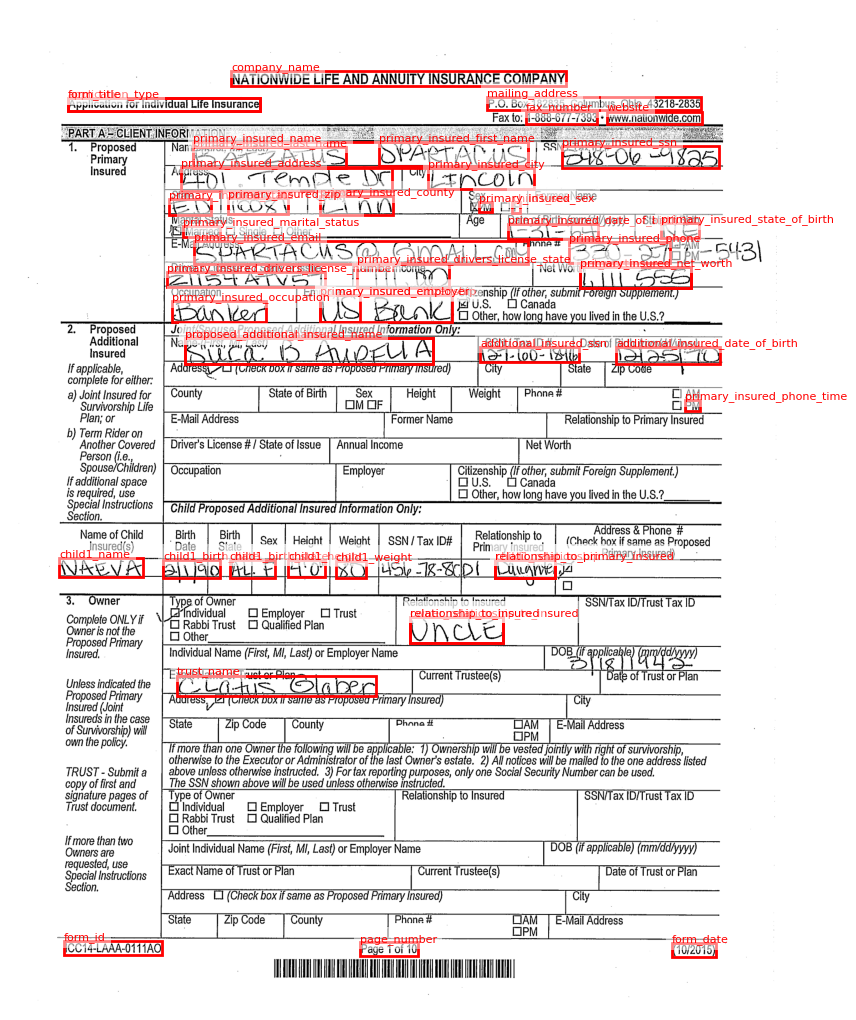

In [11]:
display_document(2)
